# Flat Transducer + Silicone Lens -> Brain Focus  (minimal)

A flat 20 mm transducer with a **plano-convex silicone lens** (slow -> converging). Two experiments:

1. **Homogeneous bath** -- the medium is "water" set to **brain properties** (c=1560, rho=1040) everywhere.
   Shows the lens's focus with no interfaces to confuse things.
2. **On the brain** -- the same transducer+lens sits on top of the brain with an **axial gap left for a phase
   plate**; everything outside the brain is **air**. Shows how the real geometry + air boundary change the focus.

| material | c (m/s) | rho (kg/m^3) |
|----------|---------|-----------|
| brain / coupling "water" | 1560 | 1040 |
| silicone lens | 1000 | 1030 |
| air (outside brain) | 343 | 100* |

\*air density is a numerical-stability floor (see params), not literal 1.2.

## 1. Imports

In [13]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from scipy import ndimage
from scipy.ndimage import gaussian_filter

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst
np.set_printoptions(suppress=True, precision=3)
print("imports OK")

imports OK


## Parameters

In [14]:
BRAIN_NII = r"C:\Users\bengi\Documents\Pesaran Lab\brain_mask.nii"

freq   = 1e6                         # Hz  (1 MHz -- near field D²/4λ ≈ 64 mm vs 32 mm at 500 kHz)
dx     = 0.5e-3                      # m   (λ/dx ≈ 5.2 PPW at 1 MHz; k-Wave pseudospectral needs ~4-5 PPW)

c_med,  rho_med  = 1560.0, 1040.0    # brain == coupling "water"
c_lens, rho_lens = 1000.0, 1030.0    # silicone
c_air            = 343.0
rho_air          = 100.0             # STABILITY FLOOR (not 1.2): air is under-resolved at
                                     # 0.5 mm and the huge density jump NaNs the solver;
                                     # 100 still reflects ~93%. Air only borders the beam.
SMOOTH_MED_VOX   = 0.6               # light smoothing of c/rho maps (k-Wave stability)

TX_DIAM  = 20e-3                      # flat transducer diameter
r_tx     = TX_DIAM/2
FOCAL    = 40e-3                      # m, lens focal length (longer -> thinner lens; targets ~60% of 64 mm near field)
P0       = 1e5                       # Pa
N_CYCLES = 5
CROP_PAD = 5e-3                      # m, margin added around an aperture/extent when sizing a sim domain
LAT_HALF = r_tx + CROP_PAD            # m, half-width of the homogeneous-bath sim domain (step 3)

# flat variable-density phase plate (constant thickness, spatially-varying c/rho)
T_PLATE     = 3e-3                    # m, flat plate thickness (fixed; set as low as feasible)
C_PLATE_MIN = 600.0                   # m/s, minimum c in plate (lower = more delay per mm of plate thickness)
TARGET_VOX  = None                    # set to the (i,j,k) FOCUS voxel from Step 4's printout for steering;
                                      # None = aim for the lens's natural on-axis focus (plate has no effect = baseline)

# step-4 placement (transducer on top of the brain, beam pointing inferior)
STANDOFF    = 8e-3                    # face -> brain-surface gap (flat plate + thinner lens = closer to brain)
R_COUPLE    = 14e-3                   # coupling-bath cylinder radius
Z_MARGIN    = 8                       # voxels above the transducer face

m2v = lambda m: m/dx
lam = c_med/freq
print(f"freq {freq/1e3:.0f} kHz | lambda(brain) {lam*1e3:.2f} mm = {lam/dx:.1f} vox")
print(f"flat-disc natural near field D^2/(4 lambda) = {(TX_DIAM**2/(4*lam))*1e3:.0f} mm; design focal {FOCAL*1e3:.0f} mm")

freq 1000 kHz | lambda(brain) 1.56 mm = 3.1 vox
flat-disc natural near field D^2/(4 lambda) = 64 mm; design focal 40 mm


## Lens design

Plano-convex silicone, flat on the transducer, convex toward the focus. Thickness `t(r)` equalises the travel
time of every ray to the on-axis focus at `FOCAL` in the brain-speed medium:

`t(r) = [sqrt(r_max^2+F^2) - sqrt(r^2+F^2)] / [c_med (1/c_lens - 1/c_med)]`  (thickest at the centre).

lens centre thickness 2.20 mm  (rim 0)


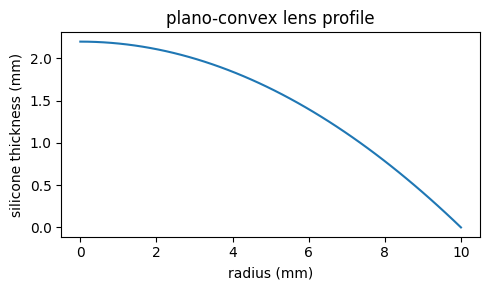

In [15]:
def lens_thickness(r):
    # r: radius (m), returns silicone thickness (m); 0 outside the aperture
    t = (np.sqrt(r_tx**2 + FOCAL**2) - np.sqrt(r**2 + FOCAL**2)) / (c_med*(1/c_lens - 1/c_med))
    return np.where(r <= r_tx, np.maximum(t, 0.0), 0.0)

def stamp_lens(c_map, rho_map, z_face, xc, yc):
    # carve the plano-convex silicone lens into a medium, on the z=z_face plane, centred (xc,yc)
    Nx, Ny, Nz = c_map.shape
    xx, yy = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing="ij")
    r = np.sqrt(((xx-xc)*dx)**2 + ((yy-yc)*dx)**2)
    tv = np.round(lens_thickness(r)/dx).astype(int)           # thickness in voxels per column
    zz = np.arange(Nz)[None,None,:]
    lens = (zz >= z_face) & (zz < z_face + tv[:,:,None]) & (r[:,:,None] <= r_tx)
    c_map[lens], rho_map[lens] = c_lens, rho_lens
    return lens

rr = np.linspace(0, r_tx, 50)
print(f"lens centre thickness {lens_thickness(np.array([0.0]))[0]*1e3:.2f} mm  (rim 0)")
plt.figure(figsize=(5,3)); plt.plot(rr*1e3, lens_thickness(rr)*1e3)
plt.xlabel("radius (mm)"); plt.ylabel("silicone thickness (mm)"); plt.title("plano-convex lens profile")
plt.tight_layout(); plt.show()

## Flat variable-density phase plate

A **flat** (constant thickness `T_PLATE`) slab placed right after the fixed lens. Instead of varying thickness,
it steers by varying the acoustic **wave speed `c(x,y)`** -- and matched **density `rho(x,y) = Z_brain/c(x,y)`**
to keep the impedance uniform across the plate and eliminate face reflections.

Design: same Fermat equal-time-delay condition as the lens, solved for `c(x,y)`:

`T_PLATE * (1/c - 1/c_med) = T0 - already(x,y)`

where `already = dist/c_med + lens_delay` is the travel-time head-start each aperture element already has via
the lens. Slow regions (`c → C_PLATE_MIN`) add extra delay; the fastest region (`c = c_med`) passes through
unaffected. The constant thickness lets the total transducer stack height be known in advance and kept small.

In [16]:
def flat_plate_medium(Nx, Ny, xc, yc, z_face, T_plate, target_vox):
    '''Design a flat variable-density plate of thickness T_plate.
    c(x,y) chosen so lens_delay + T_plate*(1/c - 1/c_med) + dist/c_med = const for every aperture element.
    rho = Z_brain/c everywhere (impedance-matched) so neither plate face causes a reflection.
    target_vox: (i,j,k) in local sim frame.'''
    xx, yy = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing="ij")
    ax_m, ay_m = (xx - xc) * dx, (yy - yc) * dx
    r = np.sqrt(ax_m**2 + ay_m**2)
    ap_mask = r <= r_tx

    tx_m, ty_m, tz_m = (np.array(target_vox, float) - [xc, yc, z_face]) * dx
    dist = np.sqrt((ax_m - tx_m)**2 + (ay_m - ty_m)**2 + tz_m**2)

    already = dist / c_med + lens_thickness(r) * (1 / c_lens - 1 / c_med)
    already_ap = np.where(ap_mask, already, np.nan)
    T0 = np.nanmax(already_ap)          # point with max "already" needs zero extra from plate (c = c_med)

    # extra delay the plate must supply: T_plate*(1/c - 1/c_med) = T0 - already
    # => c = 1 / (1/c_med + (T0-already)/T_plate)
    extra = np.clip(T0 - already, 0.0, None)
    c_des = 1.0 / (1.0 / c_med + extra / T_plate)
    c_des = np.clip(c_des, C_PLATE_MIN, c_med)

    Z_brain = rho_med * c_med
    rho_des = Z_brain / c_des          # impedance match: rho*c = Z_brain everywhere

    c_out   = np.where(ap_mask, c_des,   c_med  ).astype(np.float32)
    rho_out = np.where(ap_mask, rho_des, rho_med).astype(np.float32)

    delay_range = float(np.nanmax(already_ap) - np.nanmin(already_ap))
    capacity    = T_plate * (1.0 / C_PLATE_MIN - 1.0 / c_med)
    status = "OK" if delay_range <= capacity else "BUDGET EXCEEDED -- increase T_PLATE or lower C_PLATE_MIN"
    print(f"  flat plate: delay range {delay_range*1e6:.3f} us, capacity {capacity*1e6:.3f} us "
          f"({100*delay_range/max(capacity,1e-30):.0f}% used), c in [{c_des[ap_mask].min():.0f}, {c_med:.0f}] m/s  {status}")
    return c_out, rho_out


def stamp_flat_plate(c_map, rho_map, z_start, T_plate, c_map_2d, rho_map_2d):
    '''Stamp a flat slab of thickness T_plate starting at z_start with per-column c/rho.'''
    tv = int(round(T_plate / dx))
    z_end = min(z_start + tv, c_map.shape[2])
    c_map[:, :, z_start:z_end]   = c_map_2d[:, :, None]
    rho_map[:, :, z_start:z_end] = rho_map_2d[:, :, None]
    plate = np.zeros(c_map.shape, bool)
    plate[:, :, z_start:z_end] = True
    return plate


print("flat-plate helpers ready")

flat-plate helpers ready


## Reachable focal volume (how far can the flat plate steer?)

Pure geometry/math, no simulation: for a candidate target the flat plate must span a delay range equal to the
*spread* (max-min across the aperture) of `already(x,y) = dist/c_med + lens_delay`. The plate's total delay
capacity is `T_PLATE * (1/C_PLATE_MIN - 1/c_med)`. A target is feasible when the required delay range is within
that capacity.

By the lens's symmetry, feasibility depends only on lateral offset from the beam axis and depth -- so a 2D sweep
fully characterises the reachable volume. At the lens's own natural focus (on-axis, depth=`FOCAL`), the delay
spread is ~0 (the lens already equalises it) and the plate does nothing -- consistent with `c(x,y) = c_med`
everywhere there.

flat plate capacity: 3.077 us  (T_PLATE=3mm, C_PLATE_MIN=600 m/s)
lens centre thickness 2.20mm; stack = T_PLATE 3mm + lens 2.2mm < STANDOFF 8mm  OK
feasible region: depth 6-80 mm, lateral up to 20 mm (at the most permissive depth)


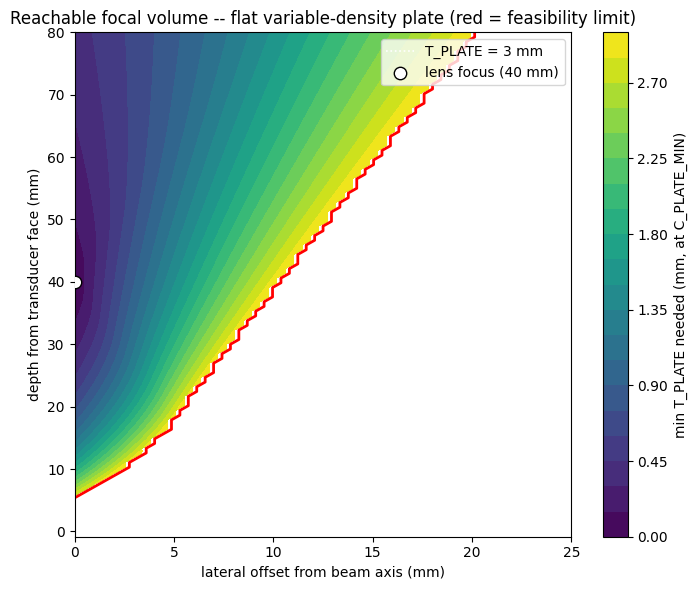

In [17]:
lens_ctr = lens_thickness(np.array([0.0]))[0]
plate_capacity = T_PLATE * (1.0 / C_PLATE_MIN - 1.0 / c_med)      # max delay range the plate can provide (s)
print(f"flat plate capacity: {plate_capacity*1e6:.3f} us  (T_PLATE={T_PLATE*1e3:.0f}mm, C_PLATE_MIN={C_PLATE_MIN:.0f} m/s)")
print(f"lens centre thickness {lens_ctr*1e3:.2f}mm; stack = T_PLATE {T_PLATE*1e3:.0f}mm + lens {lens_ctr*1e3:.1f}mm "
      f"< STANDOFF {STANDOFF*1e3:.0f}mm  {'OK' if T_PLATE+lens_ctr < STANDOFF else 'STACK EXCEEDS STANDOFF'}")

xa, ya = np.meshgrid(np.linspace(-r_tx, r_tx, 120), np.linspace(-r_tx, r_tx, 120), indexing="ij")
r_ap = np.sqrt(xa**2 + ya**2); ap_mask = r_ap <= r_tx
lt_ap = lens_thickness(r_ap)

lat_grid = np.linspace(0, 25e-3, 60)
z_grid   = np.linspace(5e-3, 80e-3, 100)       # deeper range -- near field is now ~64 mm at 1 MHz
need = np.full((len(z_grid), len(lat_grid)), np.nan)
for iz, z_t in enumerate(z_grid):
    for il, lat_t in enumerate(lat_grid):
        dist = np.sqrt((xa-lat_t)**2 + ya**2 + z_t**2)
        already = dist/c_med + lt_ap*(1/c_lens - 1/c_med)
        a = already[ap_mask]
        need[iz, il] = (a.max() - a.min()) / (1/C_PLATE_MIN - 1/c_med)   # equivalent T_PLATE needed (m)

feasible = need <= T_PLATE
print(f"feasible region: depth {z_grid[feasible.any(1)].min()*1e3:.0f}-{z_grid[feasible.any(1)].max()*1e3:.0f} mm, "
      f"lateral up to {lat_grid[feasible.any(0)].max()*1e3:.0f} mm (at the most permissive depth)")

plt.figure(figsize=(7,6))
plt.contourf(lat_grid*1e3, z_grid*1e3, np.where(feasible, need*1e3, np.nan), levels=20, cmap="viridis")
plt.colorbar(label="min T_PLATE needed (mm, at C_PLATE_MIN)")
plt.contour(lat_grid*1e3, z_grid*1e3, feasible.astype(float), levels=[0.5], colors="red", linewidths=2)
plt.axhline(T_PLATE*1e3, color="white", ls=":", lw=1.2, label=f"T_PLATE = {T_PLATE*1e3:.0f} mm")
plt.scatter([0], [FOCAL*1e3], c="white", edgecolor="k", s=80, zorder=5, label=f"lens focus ({FOCAL*1e3:.0f} mm)")
plt.xlabel("lateral offset from beam axis (mm)"); plt.ylabel("depth from transducer face (mm)")
plt.title("Reachable focal volume -- flat variable-density plate (red = feasibility limit)")
plt.legend(); plt.tight_layout(); plt.show()

## 2. Load brain

In [18]:
img = nib.load(BRAIN_NII)
brain = ndimage.binary_fill_holes(img.get_fdata() > 0.5)
brain = np.rot90(brain, k=1, axes=(0,1))   # fix: was hitting front of brain instead of top
brain = np.flip(brain, axis=1)             # fix: was upside-down after the rotation above
native_dx = float(img.header.get_zooms()[0]) * 1e-3   # m, voxel size in the NII file
if abs(native_dx - dx) > 1e-6:
    zoom_f = native_dx / dx
    brain = ndimage.zoom(brain.astype(float), zoom=zoom_f, order=1) > 0.5
    print(f"resampled brain {native_dx*1e3:.2f}mm -> {dx*1e3:.2f}mm (zoom {zoom_f:.2f}x): {brain.shape}")
NX, NY, NZ = brain.shape
C = np.argwhere(brain).mean(0)
print(f"brain {brain.shape} @ {dx*1e3:.2f} mm | axcodes {nib.aff2axcodes(img.affine)} | centroid {np.round(C,0)}")
print(f"(voxel axes (i,j,k) -> (P,I,R): superior=-j, so 'top of brain' = small j)")

brain (256, 256, 208) @ 0.50 mm | axcodes ('P', 'I', 'R') | centroid [112.  79. 100.]
(voxel axes (i,j,k) -> (P,I,R): superior=-j, so 'top of brain' = small j)


### sim + focus helpers

In [19]:
def run_sim(c_map, rho_map, z_face, xc, yc, t_end):
    Nx, Ny, Nz = c_map.shape
    kgrid = kWaveGrid([Nx, Ny, Nz], [dx, dx, dx])
    kgrid.makeTime(c_med, cfl=0.3, t_end=t_end)
    if SMOOTH_MED_VOX > 0:
        c_map   = gaussian_filter(c_map,   SMOOTH_MED_VOX).astype(np.float32)
        rho_map = gaussian_filter(rho_map, SMOOTH_MED_VOX).astype(np.float32)
    medium = kWaveMedium(sound_speed=c_map, density=rho_map)
    disc = (np.sqrt((np.arange(Nx)[:,None]-xc)**2 + (np.arange(Ny)[None,:]-yc)**2)*dx) <= r_tx
    src = kSource(); src.p_mask = np.zeros((Nx,Ny,Nz), np.uint8); src.p_mask[:,:,z_face] = disc
    src.p = (tone_burst(1/kgrid.dt, freq, N_CYCLES).flatten()*P0).reshape(1,-1)   # flat, in-phase
    sen = kSensor(); sen.mask = np.ones((Nx,Ny,Nz), np.uint8); sen.record = ["p_max"]
    print(f"  grid {Nx}x{Ny}x{Nz}  Nt {kgrid.Nt}  ... running (GPU)")
    sd = kspaceFirstOrder(kgrid, medium, src, sen, device="gpu", dtype="float32")
    p = np.zeros((Nx,Ny,Nz), np.float32); p[sen.mask.astype(bool)] = np.squeeze(np.asarray(sd["p_max"]))
    nbad = int((~np.isfinite(p)).sum())
    if nbad: print(f"  WARNING {nbad} non-finite voxels -> instability; zeroing"); p = np.nan_to_num(p)
    return p

def focus_of(p, mask=None):
    pm = np.nan_to_num(p if mask is None else np.where(mask, p, 0.0))
    fi = np.unravel_index(np.argmax(pm), pm.shape)
    return fi, float(pm.max())
print("helpers ready")

helpers ready


## 3. Lens in a homogeneous bath (water = brain)

Medium is brain-property "water" everywhere, with the silicone lens on the transducer face. A flat in-phase disc
fires; the lens focuses it. We read off the focal depth from the transducer face.

In [20]:
Nx = Ny = 2*int(round(m2v(LAT_HALF)))
Nz = Z_MARGIN + int(round(m2v(FOCAL))) + 28
xc = yc = Nx//2; z_face = Z_MARGIN

c_map   = np.full((Nx,Ny,Nz), c_med,   np.float32)
rho_map = np.full((Nx,Ny,Nz), rho_med, np.float32)
lens = stamp_lens(c_map, rho_map, z_face, xc, yc)

t_end = 1.2*(Nz*dx)/c_med
p3 = run_sim(c_map.copy(), rho_map.copy(), z_face, xc, yc, t_end)
fi, pk = focus_of(p3, mask=~lens)   # exclude the lens: its own near-source resonance can outpeak the true downstream focus
depth = (fi[2]-z_face)*dx*1e3
print(f"FOCUS voxel {fi} | depth from face {depth:.1f} mm (design ref {FOCAL*1e3:.0f}) | "
      f"lateral off-axis {np.hypot(fi[0]-xc,fi[1]-yc)*dx*1e3:.1f} mm | peak {pk/1e3:.1f} kPa")

  grid 60x60x116  Nt 465  ... running (GPU)


k-Wave: 100%|██████████| 465/465 [00:01<00:00, 264.23step/s]


FOCUS voxel (np.int64(30), np.int64(30), np.int64(63)) | depth from face 27.5 mm (design ref 40) | lateral off-axis 0.0 mm | peak 279.0 kPa


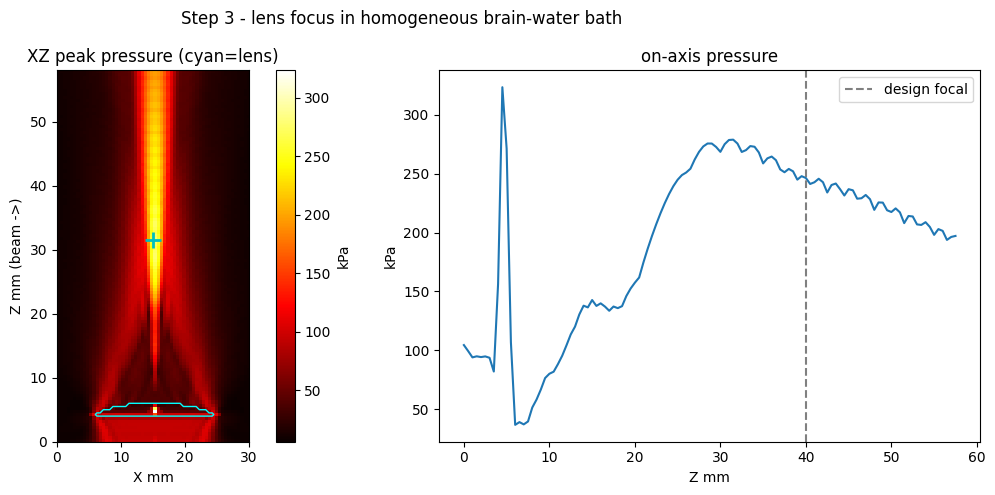

In [21]:
ex=[0,Nx*dx*1e3]; ez=[0,Nz*dx*1e3]
fig,ax=plt.subplots(1,2,figsize=(12,5))
im=ax[0].imshow(p3[:,yc,:].T/1e3,origin="lower",extent=ex+ez,cmap="hot",aspect="equal")
ax[0].contour(lens[:,yc,:].T,levels=[0.5],colors="cyan",linewidths=1,extent=ex+ez,origin="lower")
ax[0].plot(fi[0]*dx*1e3, fi[2]*dx*1e3,"c+",ms=12,mew=2)
ax[0].set(title="XZ peak pressure (cyan=lens)",xlabel="X mm",ylabel="Z mm (beam ->)"); plt.colorbar(im,ax=ax[0],label="kPa")
ax[1].plot(np.arange(Nz)*dx*1e3, p3[xc,yc,:]/1e3)
ax[1].axvline(FOCAL*1e3,ls="--",c="gray",label="design focal")
ax[1].set(title="on-axis pressure",xlabel="Z mm",ylabel="kPa"); ax[1].legend()
plt.suptitle("Step 3 - lens focus in homogeneous brain-water bath"); plt.tight_layout(); plt.show()

## 4. Transducer + lens on top of the brain (air outside, gap for phase plate)

Crop a block at the picked transducer pose (beam = local +Z). If `transducer_location.json` exists (saved by
`place_transducer.py`), the brain is **rotated into that beam-aligned frame**; otherwise it defaults to straight-up
at the brain's superior-most point. The transducer+lens sits a `STANDOFF` above the brain surface; the space
between the lens and the brain is coupling "water" (= brain) and **is where the phase plate will go**. Everything
outside the brain (and outside the coupling cylinder) is **air**.

In [22]:
# transducer pose: load the picked location from place_transducer.py if saved, else default to straight-up
TX_JSON = "transducer_location.json"
if os.path.exists(TX_JSON):
    tj = json.load(open(TX_JSON))
    face_vox = np.array(tj["transducer_face_center_voxel"], float)
    n_out = np.array(tj["beam_normal_voxel"], float); n_out /= np.linalg.norm(n_out)
    standoff_use = tj["standoff_mm"]*1e-3
    print(f"using PICKED pose from {TX_JSON}: beam {tj['equiv_angles_deg']}, standoff {tj['standoff_mm']} mm, {tj['anat_offset']}")
else:
    ic0, kc0 = int(round(C[0])), int(round(C[2]))
    j_top = int(np.argmax(brain[ic0, :, kc0]))
    n_out = np.array([0., -1., 0.])                        # outward = superior = -j
    face_vox = np.array([ic0, j_top, kc0], float) + n_out*m2v(STANDOFF)
    standoff_use = STANDOFF
    print(f"no {TX_JSON} found -> default straight-up placement at brain top")

# rotate the brain into a beam-aligned local frame: local +z (last axis) = beam direction (into the brain)
beam = -n_out; e3 = beam/np.linalg.norm(beam)
tmp = np.array([0.,0.,1.]) if abs(e3[2]) < 0.9 else np.array([1.,0.,0.])
e1 = np.cross(tmp, e3); e1 /= np.linalg.norm(e1); e2 = np.cross(e3, e1)
Mrot = np.stack([e1, e2, e3])                              # local = Mrot @ (world_vox - origin)

# size the crop to cover the WHOLE brain, not a small patch: project every brain voxel into this
# beam-aligned frame and take its full extent + a margin. This is much bigger than the old fixed-size
# patch -> the sim below will take a lot longer and use a lot more memory.
local = (np.argwhere(brain) - face_vox) @ Mrot.T            # columns = e1,e2,e3 coords relative to face
pad = m2v(CROP_PAD)
soff = int(round(m2v(standoff_use)))
LAT  = int(np.ceil(np.abs(local[:,:2]).max() + pad))
Nx = Ny = 2*LAT; xc = yc = LAT; z_face = Z_MARGIN
Nz = Z_MARGIN + int(np.ceil(local[:,2].max() + pad))
origin = face_vox - e3*z_face
offset = origin - Mrot.T @ np.array([xc, yc, 0.])
brain_W = ndimage.affine_transform(brain.astype(np.float32), matrix=Mrot.T, offset=offset,
                                    output_shape=(Nx,Ny,Nz), order=1) > 0.5
nvox = Nx*Ny*Nz
print(f"crop {brain_W.shape} = {Nx*dx*1e3:.0f}x{Ny*dx*1e3:.0f}x{Nz*dx*1e3:.0f} mm ({nvox/1e6:.1f}M voxels, whole brain)")
print(f"beam dir (voxel) {np.round(beam,3)}  brain top at z={soff+z_face} (= {standoff_use*1e3:.0f} mm below face)")

# clearance check: the standoff gap (face -> brain) must be brain-free under the transducer itself (r_tx),
# and ideally under the wider coupling margin (R_COUPLE) too, since brain curvature can intrude there first
xx0,yy0 = np.meshgrid(np.arange(Nx),np.arange(Ny),indexing="ij")
rad = np.sqrt((xx0-xc)**2+(yy0-yc)**2)*dx
gap = brain_W[:,:,z_face:z_face+soff]
nbad_tx     = int(gap[rad <= r_tx].sum())
nbad_couple = int(gap[rad <= R_COUPLE].sum())
print(f"clearance check: brain voxels in standoff gap -- under transducer (r<={r_tx*1e3:.0f}mm): {nbad_tx} (want 0)"
      f"{'  TOO CLOSE!' if nbad_tx else '  OK'}; "
      f"under coupling margin (r<={R_COUPLE*1e3:.0f}mm): {nbad_couple}"
      f"{'  (rim only, OK if 0 under transducer)' if nbad_couple and not nbad_tx else ''}")

no transducer_location.json found -> default straight-up placement at brain top
crop (176, 176, 139) = 88x88x70 mm (4.3M voxels, whole brain)
beam dir (voxel) [-0.  1. -0.]  brain top at z=24 (= 8 mm below face)
clearance check: brain voxels in standoff gap -- under transducer (r<=10mm): 0 (want 0)  OK; under coupling margin (r<=14mm): 0


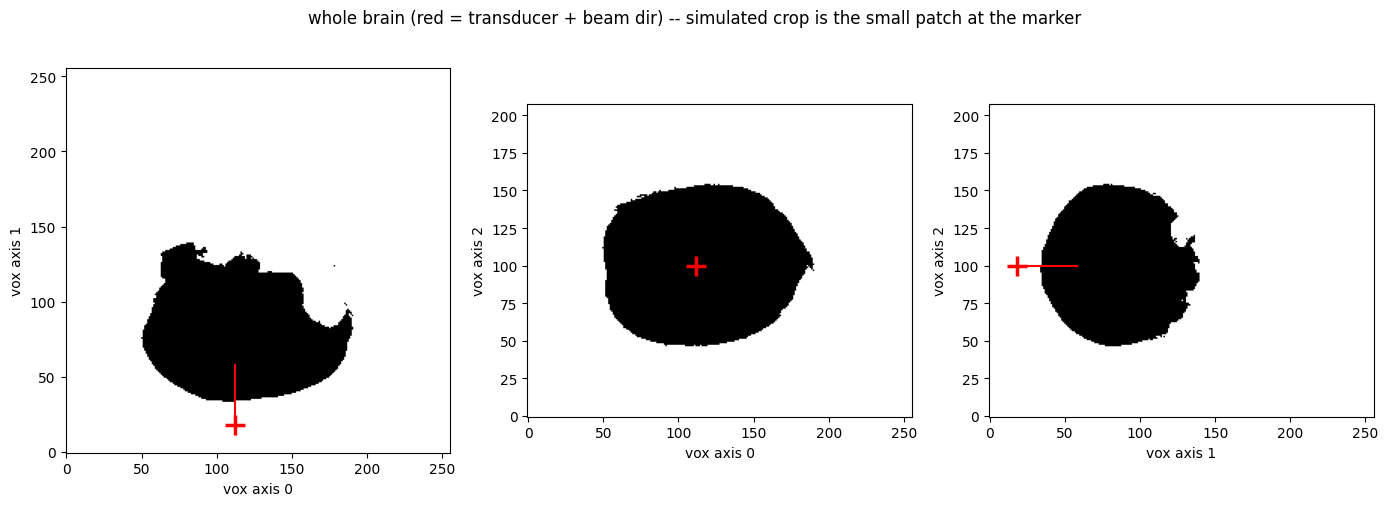

In [23]:
# whole-brain context: the simulation only covers a small crop around the transducer (compute cost) --
# this shows where that crop sits on the FULL brain, before spending time running the sim
bij = brain.any(2); bik = brain.any(1); bjk = brain.any(0)   # full-brain outlines, native (i,j,k) frame
fig,ax = plt.subplots(1,3,figsize=(14,5))
for a,foot,(h,v) in zip(ax, [bij,bik,bjk], [(0,1),(0,2),(1,2)]):
    a.imshow(foot.T, origin="lower", cmap="gray_r", aspect="equal")
    a.plot(face_vox[h], face_vox[v], "r+", ms=14, mew=2.5)
    a.plot([face_vox[h], face_vox[h]+beam[h]*40], [face_vox[v], face_vox[v]+beam[v]*40], "r-", lw=1.5)
    a.set(xlabel=f"vox axis {h}", ylabel=f"vox axis {v}")
plt.suptitle("whole brain (red = transducer + beam dir) -- simulated crop is the small patch at the marker")
plt.tight_layout(); plt.show()

In [24]:
# per-column brain surface + coupling cylinder (water=brain) between face and brain
surfz = np.full((Nx,Ny), Nz, int); anyb = brain_W.any(2); surfz[anyb] = brain_W.argmax(2)[anyb]
xx,yy = np.meshgrid(np.arange(Nx),np.arange(Ny),indexing="ij")
r2d = np.sqrt(((xx-xc)*dx)**2+((yy-yc)*dx)**2); zz=np.arange(Nz)[None,None,:]
couple = (r2d<=R_COUPLE)[:,:,None] & (zz>=z_face) & (zz<surfz[:,:,None]) & ~brain_W

c_map   = np.full((Nx,Ny,Nz), c_air,   np.float32)
rho_map = np.full((Nx,Ny,Nz), rho_air, np.float32)
c_map[couple]=c_med;  rho_map[couple]=rho_med
c_map[brain_W]=c_med; rho_map[brain_W]=rho_med            # brain == water
lensW = stamp_lens(c_map, rho_map, z_face, xc, yc)

z_plate = z_face + int(lensW.sum(2).max())               # right after the lens
tv_use = TARGET_VOX if TARGET_VOX is not None else (xc, yc, z_face + int(m2v(FOCAL)))
off_mm = (np.array(tv_use, float) - [xc, yc, z_face]) * dx * 1e3
print(f"flat plate target: {tv_use} = {np.round(off_mm,1)} mm (x,y,z) from face")
c_2d, rho_2d = flat_plate_medium(Nx, Ny, xc, yc, z_face, T_PLATE, tv_use)
plateW = stamp_flat_plate(c_map, rho_map, z_plate, T_PLATE, c_2d, rho_2d)
nbad_plate = int((plateW & brain_W).sum())
print(f"flat plate: z [{z_plate}, {z_plate+int(round(T_PLATE/dx))}), T_PLATE {T_PLATE*1e3:.1f} mm, "
      f"overlap with brain: {nbad_plate}{'  TOO DEEP!' if nbad_plate else '  OK'}")

tissue = np.zeros((Nx,Ny,Nz),np.uint8); tissue[couple]=1; tissue[brain_W]=2; tissue[lensW]=3; tissue[plateW]=4
t_end = 1.2*(Nz*dx)/c_med
p4 = run_sim(c_map.copy(), rho_map.copy(), z_face, xc, yc, t_end)
fi4, pk4 = focus_of(p4, mask=brain_W)
print(f"FOCUS voxel {fi4} | depth below brain surface {(fi4[2]-surfz[fi4[0],fi4[1]])*dx*1e3:.1f} mm | peak {pk4/1e3:.1f} kPa")

flat plate target: (88, 88, 88) = [ 0.  0. 40.] mm (x,y,z) from face
  flat plate: delay range 0.000 us, capacity 3.077 us (0% used), c in [1560, 1560] m/s  OK
flat plate: z [12, 18), T_PLATE 3.0 mm, overlap with brain: 0  OK
  grid 176x176x139  Nt 558  ... running (GPU)


k-Wave: 100%|██████████| 558/558 [04:31<00:00,  2.05step/s]


FOCUS voxel (np.int64(88), np.int64(89), np.int64(108)) | depth below brain surface 41.5 mm | peak 480.4 kPa


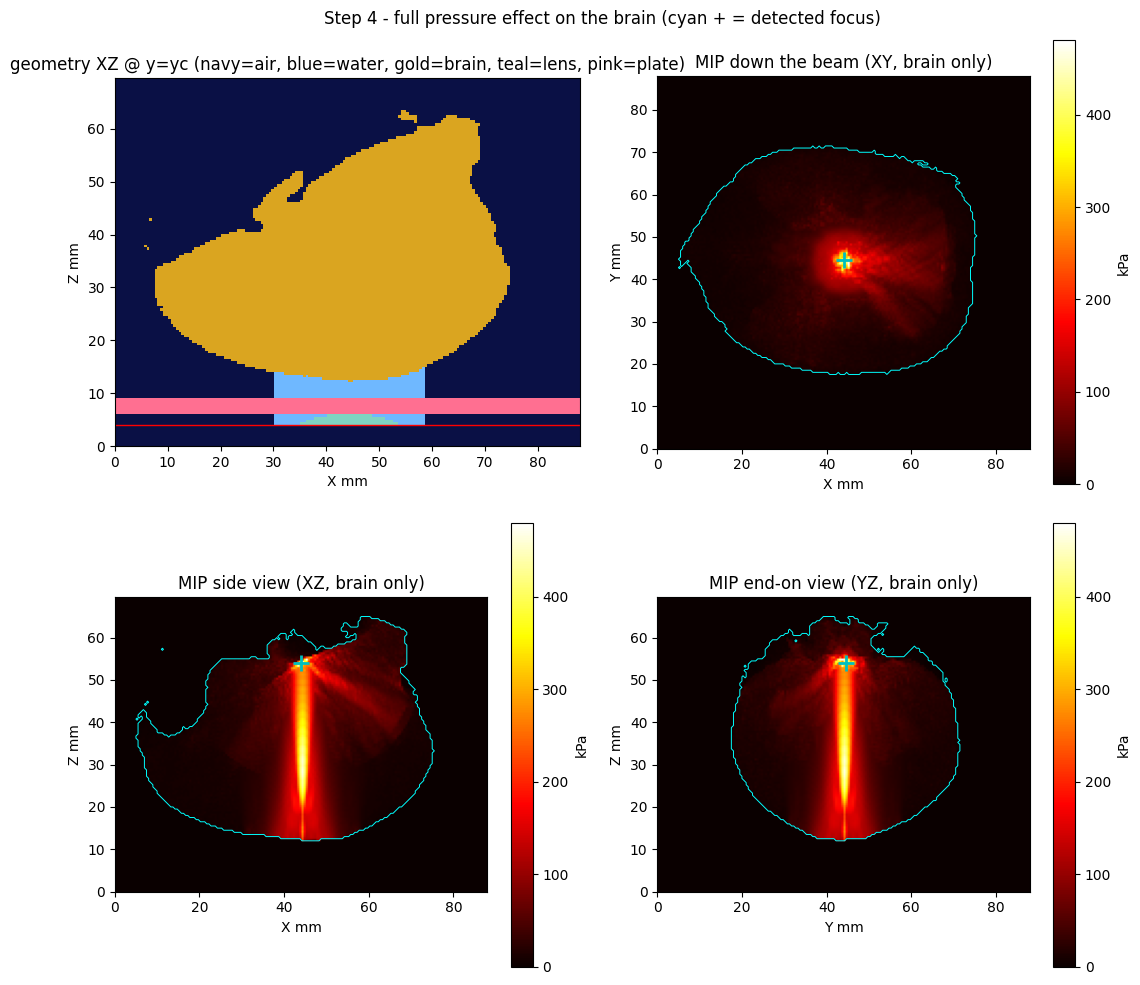

In [25]:
ex=[0,Nx*dx*1e3]; ez=[0,Nz*dx*1e3]; ey=[0,Ny*dx*1e3]
cmap4=plt.matplotlib.colors.ListedColormap(["#0a1045","#6fb8ff","#daa520","#7fd4c1","#ff6f91"])  # air,water,brain,lens,plate

# full effect on the brain: max-intensity projections (brain tissue only), not just one slice,
# so an off-axis or steered focus can't hide outside a single chosen plane
pB = np.where(brain_W, p4, 0.0)
mip_xy = pB.max(2); mip_xz = pB.max(1); mip_yz = pB.max(0)   # down-the-beam / side / end-on
vmax = pB.max()/1e3

fig,ax=plt.subplots(2,2,figsize=(11,10))
ax[0,0].imshow(tissue[:,yc,:].T,origin="lower",extent=ex+ez,cmap=cmap4,vmin=0,vmax=4,aspect="equal",interpolation="nearest")
ax[0,0].axhline(z_face*dx*1e3,c="r",lw=1)
ax[0,0].set(title="geometry XZ @ y=yc (navy=air, blue=water, gold=brain, teal=lens, pink=plate)",xlabel="X mm",ylabel="Z mm")

im=ax[0,1].imshow(mip_xy.T/1e3,origin="lower",extent=ex+ey,cmap="hot",vmin=0,vmax=vmax,aspect="equal")
ax[0,1].contour(brain_W.any(2).T,levels=[0.5],colors="cyan",linewidths=0.7,extent=ex+ey,origin="lower")
ax[0,1].plot(fi4[0]*dx*1e3, fi4[1]*dx*1e3,"c+",ms=12,mew=2)
ax[0,1].set(title="MIP down the beam (XY, brain only)",xlabel="X mm",ylabel="Y mm"); plt.colorbar(im,ax=ax[0,1],label="kPa")

im=ax[1,0].imshow(mip_xz.T/1e3,origin="lower",extent=ex+ez,cmap="hot",vmin=0,vmax=vmax,aspect="equal")
ax[1,0].contour(brain_W.any(1).T,levels=[0.5],colors="cyan",linewidths=0.7,extent=ex+ez,origin="lower")
ax[1,0].plot(fi4[0]*dx*1e3, fi4[2]*dx*1e3,"c+",ms=12,mew=2)
ax[1,0].set(title="MIP side view (XZ, brain only)",xlabel="X mm",ylabel="Z mm"); plt.colorbar(im,ax=ax[1,0],label="kPa")

im=ax[1,1].imshow(mip_yz.T/1e3,origin="lower",extent=ey+ez,cmap="hot",vmin=0,vmax=vmax,aspect="equal")
ax[1,1].contour(brain_W.any(0).T,levels=[0.5],colors="cyan",linewidths=0.7,extent=ey+ez,origin="lower")
ax[1,1].plot(fi4[1]*dx*1e3, fi4[2]*dx*1e3,"c+",ms=12,mew=2)
ax[1,1].set(title="MIP end-on view (YZ, brain only)",xlabel="Y mm",ylabel="Z mm"); plt.colorbar(im,ax=ax[1,1],label="kPa")

plt.suptitle("Step 4 - full pressure effect on the brain (cyan + = detected focus)")
plt.tight_layout(); plt.show()

## 5. Simulate the reachable-volume extremes on the brain

Pick a handful of boundary points from the reachable-volume sweep (a few lateral offsets, each at its shallowest
and deepest still-feasible depth), aim a *targeted* phase plate at each (reusing the Step 4 pose), and actually
simulate them. Each point gets its own small LOCAL crop sized just for that target -- not the whole brain -- since
we already know roughly where to look from the math above, so this is much cheaper than Step 4's whole-brain run
per point. Expect this to take a while regardless: it's N simulations back to back, just smaller ones.

In [26]:
# a few lateral offsets (as fractions of the max feasible lateral), each at its shallowest/deepest
# still-feasible depth -- trim the fractions list to run fewer/cheaper points
lat_feasible = feasible.any(0)
li_max = np.where(lat_feasible)[0].max()
test_li = sorted(set(int(f*li_max) for f in [0.0, 0.5, 0.85, 1.0]))
targets = []                                              # (lat_m, z_m, label)
for li in test_li:
    col = feasible[:, li]
    if not col.any(): continue
    zs = z_grid[col]; lat_m = lat_grid[li]
    targets.append((lat_m, zs.min(), f"lat{lat_m*1e3:.0f}_shallow"))
    if zs.max() > zs.min():
        targets.append((lat_m, zs.max(), f"lat{lat_m*1e3:.0f}_deep"))
print(f"{len(targets)} extreme points to simulate:")
for lat_m, z_m, lbl in targets: print(f"  {lbl}: lateral {lat_m*1e3:.0f}mm, depth {z_m*1e3:.0f}mm")

8 extreme points to simulate:
  lat0_shallow: lateral 0mm, depth 6mm
  lat0_deep: lateral 0mm, depth 80mm
  lat10_shallow: lateral 10mm, depth 38mm
  lat10_deep: lateral 10mm, depth 80mm
  lat17_shallow: lateral 17mm, depth 66mm
  lat17_deep: lateral 17mm, depth 80mm
  lat20_shallow: lateral 20mm, depth 79mm
  lat20_deep: lateral 20mm, depth 80mm


In [ ]:
PML_SIZE = 20   # k-Wave default; validate_pml requires 2*PML_SIZE < N on every axis

def run_target_sim(lat_t, z_t):
    # small LOCAL crop sized just for this one target (not the whole brain), reusing the Step 4 pose
    # (face_vox, e1, e2, e3, Mrot) -- target sits at lateral offset lat_t along e1, depth z_t along e3
    margin = 8e-3
    LATc = max(int(np.ceil(m2v(abs(lat_t) + r_tx + margin))), PML_SIZE + 1)
    Zc   = max(Z_MARGIN + int(np.ceil(m2v(z_t + margin))), 2*PML_SIZE + 1)
    Nxc = Nyc = 2*LATc; xcc = ycc = LATc; zfc = Z_MARGIN
    origin_c = face_vox - e3*zfc
    offset_c = origin_c - Mrot.T @ np.array([xcc, ycc, 0.])
    brain_c = ndimage.affine_transform(brain.astype(np.float32), matrix=Mrot.T, offset=offset_c,
                                        output_shape=(Nxc,Nyc,Zc), order=1) > 0.5

    surfz_c = np.full((Nxc,Nyc), Zc, int); anyb_c = brain_c.any(2); surfz_c[anyb_c] = brain_c.argmax(2)[anyb_c]
    xxc,yyc = np.meshgrid(np.arange(Nxc),np.arange(Nyc),indexing="ij")
    r2d_c = np.sqrt(((xxc-xcc)*dx)**2+((yyc-ycc)*dx)**2); zzc = np.arange(Zc)[None,None,:]
    couple_c = (r2d_c<=R_COUPLE)[:,:,None] & (zzc>=zfc) & (zzc<surfz_c[:,:,None]) & ~brain_c

    c_map_c   = np.full((Nxc,Nyc,Zc), c_air,   np.float32)
    rho_map_c = np.full((Nxc,Nyc,Zc), rho_air, np.float32)
    c_map_c[couple_c]=c_med;  rho_map_c[couple_c]=rho_med
    c_map_c[brain_c]=c_med;   rho_map_c[brain_c]=rho_med
    lens_c = stamp_lens(c_map_c, rho_map_c, zfc, xcc, ycc)

    target_vox_c = (xcc + m2v(lat_t), ycc, zfc + m2v(z_t))
    z_plate_c = zfc + int(lens_c.sum(2).max())
    c_2d_c, rho_2d_c = flat_plate_medium(Nxc, Nyc, xcc, ycc, zfc, T_PLATE, target_vox_c)
    stamp_flat_plate(c_map_c, rho_map_c, z_plate_c, T_PLATE, c_2d_c, rho_2d_c)

    t_end_c = 1.2*(Zc*dx)/c_med
    p_c = run_sim(c_map_c.copy(), rho_map_c.copy(), zfc, xcc, ycc, t_end_c)
    fi_c, pk_c = focus_of(p_c, mask=brain_c)

    return dict(
        lat_mm=lat_t*1e3, z_mm=z_t*1e3, plate_t_mm=T_PLATE*1e3, peak_kPa=pk_c/1e3,
        global_target=face_vox + (lat_t/dx)*e1 + (z_t/dx)*e3,
        global_focus=face_vox + (fi_c[0]-xcc)*e1 + (fi_c[1]-ycc)*e2 + (fi_c[2]-zfc)*e3,
        achieved_lat_mm=np.hypot(fi_c[0]-xcc, fi_c[1]-ycc)*dx*1e3,
        achieved_z_mm=(fi_c[2]-zfc)*dx*1e3)

results = []
for i, (lat_t, z_t, lbl) in enumerate(targets):
    print(f"[{i+1}/{len(targets)}] {lbl}: target lateral {lat_t*1e3:.0f}mm depth {z_t*1e3:.0f}mm")
    results.append(run_target_sim(lat_t, z_t))
    r = results[-1]
    print(f"  -> achieved lateral {r['achieved_lat_mm']:.1f}mm depth {r['achieved_z_mm']:.1f}mm, "
          f"plate T {r['plate_t_mm']:.1f}mm (fixed), peak {r['peak_kPa']:.0f} kPa")

### Show the extremes on the brain

In [ ]:
bij = brain.any(2); bik = brain.any(1); bjk = brain.any(0)
ach_depths = [r['achieved_z_mm'] for r in results]   # colour by achieved depth (all targets use same T_PLATE)
fig, ax = plt.subplots(1, 3, figsize=(15,5))
for a, foot, (h,v) in zip(ax, [bij,bik,bjk], [(0,1),(0,2),(1,2)]):
    a.imshow(foot.T, origin="lower", cmap="gray_r", aspect="equal")
    a.plot(face_vox[h], face_vox[v], "k+", ms=10, mew=2)
    sca = a.scatter([r['global_target'][h] for r in results], [r['global_target'][v] for r in results],
                     c=ach_depths, cmap="plasma", s=80, edgecolor="k", zorder=5)
    a.scatter([r['global_focus'][h] for r in results], [r['global_focus'][v] for r in results],
              marker="x", c="cyan", s=60, zorder=6)
    a.set(xlabel=f"vox axis {h}", ylabel=f"vox axis {v}")
plt.colorbar(sca, ax=ax, label="achieved focus depth (mm)", shrink=0.7)
fig.suptitle(f"Reachable-volume extremes (dot=target, x=achieved, colour=achieved depth, T_PLATE={T_PLATE*1e3:.0f}mm fixed)")
plt.tight_layout(); plt.show()

print(f"\n{'label':14s} {'lat_mm':>7s} {'z_mm':>6s} {'plate_t_mm':>10s} {'peak_kPa':>9s} {'achiev_lat':>11s} {'achiev_z':>9s}")
for (lat_t,z_t,lbl), r in zip(targets, results):
    print(f"{lbl:14s} {r['lat_mm']:7.1f} {r['z_mm']:6.1f} {r['plate_t_mm']:10.1f} {r['peak_kPa']:9.0f} "
          f"{r['achieved_lat_mm']:11.1f} {r['achieved_z_mm']:9.1f}")

## 6. Flat plate design visualisation

Inspect the `c(x,y)` and `rho(x,y)` maps that the flat plate uses for the Step 4 target. Slow (blue) regions
add delay to slow down the faster-arriving ray paths; the `c = c_med` (pass-through) rim surrounds the aperture.
Impedance matching keeps `rho*c = Z_brain` everywhere, so neither face of the slab causes a reflection.

In [ ]:
# requires Nx, Ny, xc, yc, z_face from Step 4 -- run Step 4 first
tv_vis = TARGET_VOX if TARGET_VOX is not None else (xc, yc, z_face + int(m2v(FOCAL)))
c_vis, rho_vis = flat_plate_medium(Nx, Ny, xc, yc, z_face, T_PLATE, tv_vis)

xx_m = (np.arange(Nx) - xc) * dx * 1e3
yy_m = (np.arange(Ny) - yc) * dx * 1e3
tgt_x_mm = (tv_vis[0] - xc) * dx * 1e3
tgt_y_mm = (tv_vis[1] - yc) * dx * 1e3

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im0 = ax[0].imshow(c_vis[:, :].T, origin="lower",
                    extent=[xx_m[0], xx_m[-1], yy_m[0], yy_m[-1]],
                    cmap="RdBu_r", vmin=C_PLATE_MIN, vmax=c_med, aspect="equal")
ax[0].set(title=f"c(x,y)  [m/s]   T_PLATE={T_PLATE*1e3:.0f}mm", xlabel="x mm", ylabel="y mm")
plt.colorbar(im0, ax=ax[0], label="wave speed (m/s)")
ax[0].add_patch(plt.Circle((0,0), r_tx*1e3, fill=False, color='k', lw=1.5))
ax[0].plot(tgt_x_mm, tgt_y_mm, 'w+', ms=14, mew=2.5)

im1 = ax[1].imshow(rho_vis[:, :].T, origin="lower",
                    extent=[xx_m[0], xx_m[-1], yy_m[0], yy_m[-1]],
                    cmap="RdBu", aspect="equal")
ax[1].set(title="rho(x,y)  [kg/m^3]  (impedance-matched: rho*c = Z_brain)", xlabel="x mm", ylabel="y mm")
plt.colorbar(im1, ax=ax[1], label="density (kg/m^3)")
ax[1].add_patch(plt.Circle((0,0), r_tx*1e3, fill=False, color='k', lw=1.5))
ax[1].plot(tgt_x_mm, tgt_y_mm, 'k+', ms=14, mew=2.5)

plt.suptitle("Step 6 -- flat plate acoustic property maps  (+ marks target direction)")
plt.tight_layout(); plt.show()